# Reinforcement Learning Model Analysis 

In [94]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from typing import Dict, List, Callable

from rliable import library as rly
from rliable import metrics
from rliable import plot_utils

np.random.default_rng(42)

#change this to respective path
FEUDAL_FILE = '/Users/jojona/Documents/Learning/Masters/COMPSCI 760/COMPSCI_760_Reinforcement/Atari/model_data/feudal_MsPacman-v5'
QLEARN_FILE = '/Users/jojona/Documents/Learning/Masters/COMPSCI 760/COMPSCI_760_Reinforcement/Atari/model_data/qlearn_MsPacman-v5'

ALGORITHMS = {
    'Feudal': FEUDAL_FILE,
    'DQN': QLEARN_FILE
}

# Plotting colors for consistency
COLORS = {
    'Feudal': '#377eb8',
    'DQN': "#058f2a",
    'Feudal_Profile': '#7645df',
    'Q_Profile': '#37b85c'
}
RANDOM_SCORE = 307.3
HUMAN_SCORE = 6957.0


In [ ]:
# Help funcs

def load_scores(file_path: str) -> np.ndarray:
    """Loads scores from a JSON file and returns them as a NumPy array."""
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        

        scores_series = pd.Series(data.values())
        return pd.to_numeric(scores_series, errors='coerce').dropna().values

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return np.array([])

def plot_score_distribution(scores: np.ndarray, algo_name: str):
    """Plots the score distribution histogram with mean, median, and IQM."""
    if scores.size == 0:
        print(f"No scores to plot for {algo_name}.")
        return

    mean_score = np.mean(scores)
    median_score = np.median(scores)
    q1, q3 = np.percentile(scores, [25, 75])
    iqm_scores = scores[(scores >= q1) & (scores <= q3)]
    iqm_score = np.mean(iqm_scores) if iqm_scores.size > 0 else median_score

    plt.figure(figsize=(10, 6))
    sns.histplot(scores, bins=20, kde=True, color='skyblue')
    plt.axvline(mean_score, color='red', linestyle='--', lw=2, label=f'Mean: {mean_score:.2f}')
    plt.axvline(median_score, color='green', linestyle='--', lw=2, label=f'Median: {median_score:.2f}')
    plt.axvline(iqm_score, color='purple', linestyle='--', lw=2, label=f'IQM: {iqm_score:.2f}')
    plt.title(f'Score Distribution of {algo_name} on Ms. Pac-Man', fontsize=16)
    plt.xlabel('Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.show()

def plot_score_distributions_overlapped(scores_dict: dict):
    """
    Plots score distribution histograms for two algorithms overlapped in one figure,
    with mean, median, and IQM for each.

    Args:
        scores_dict: A dictionary where keys are algorithm names and values are score arrays.
                     This function is designed to plot exactly two algorithms for comparison.
    """
    if len(scores_dict) != 2:
        print("This function is designed to plot exactly two score distributions for comparison.")
        return

    sns.set_style("whitegrid")
    fig, ax = plt.subplots(1, 1, figsize=(12, 7)) # Create a single subplot
    fig.suptitle('Comparison of Score Distributions on Ms. Pac-Man', fontsize=18)
    
    # Define distinct colors for each algorithm's histogram and its corresponding lines
    hist_colors = ['skyblue', 'salmon']
    
    # Define distinct line styles for Mean, Median, and IQM to differentiate them
    line_styles = ['--', '-', ':'] 
    
    algo_names = list(scores_dict.keys())

    for i, algo_name in enumerate(algo_names):
        scores = scores_dict[algo_name]

        if scores.size == 0:
            print(f"Warning: No scores to plot for {algo_name}. Skipping this distribution.")
            continue

        mean_score = np.mean(scores)
        median_score = np.median(scores)
        q1, q3 = np.percentile(scores, [25, 75])
        iqm_scores = scores[(scores >= q1) & (scores <= q3)]
        iqm_score = np.mean(iqm_scores) if iqm_scores.size > 0 else median_score

        # Plot histogram with transparency (alpha) so both distributions are visible
        sns.histplot(scores, bins=20, kde=True, color=hist_colors[i], ax=ax, alpha=0.5, label=f'{algo_name} Distribution')
        
        # Plot vertical lines for mean, median, and IQM
        current_color = hist_colors[i]
        
        ax.axvline(mean_score, color=current_color, linestyle=line_styles[0], lw=2, label=f'{algo_name} Mean: {mean_score:.2f}')
        ax.axvline(median_score, color=current_color, linestyle=line_styles[1], lw=2, label=f'{algo_name} Median: {median_score:.2f}')
        ax.axvline(iqm_score, color=current_color, linestyle=line_styles[2], lw=2, label=f'{algo_name} IQM: {iqm_score:.2f}')
    
    # Set common labels for the single plot
    ax.set_xlabel('Score', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    
    # Place the legend outside the plot area to prevent it from overlapping with the histograms and lines.
    ax.legend(title='Metrics', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    
    # Adjust layout to make space for the legend on the right
    plt.tight_layout(rect=[0, 0.03, 0.85, 0.95])
    plt.show()


def plot_annotated_profile(scores: np.ndarray, profile: np.ndarray, thresholds: np.ndarray, algo_name: str, color: str):
    """Plots a detailed performance profile with IQM and Optimality Gap shaded."""
    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.plot(thresholds, profile, color=color, linewidth=2.5)

    human_level_mask = thresholds <= metrics.aggregate_iqm(qlearning_scores)
    ax.fill_between(thresholds[human_level_mask], profile[human_level_mask], 1,
                    color='orange', alpha=0.7, label='Optimality Gap')
    
    custom_y_val = np.interp(metrics.aggregate_iqm(qlearning_scores), thresholds, profile)
    y_lim_top = ax.get_ylim()[1]
            # Draw the line from the top (ymax=1.0) down to the profile curve (ymin=...)
    ax.axvline(x=metrics.aggregate_iqm(qlearning_scores), ymin=(custom_y_val / y_lim_top), ymax=1.0, color='black', linestyle='-.', lw=2, label=f'DQN IQM = {metrics.aggregate_iqm(qlearning_scores):.4f}')

    x_25, x_75 = np.percentile(scores, [25, 75])
    iqm_mask = (thresholds >= x_25) & (thresholds <= x_75)
    ax.fill_between(thresholds[iqm_mask], profile[iqm_mask], 0,
                    color='red', alpha=0.7, label='IQM')

    y_25 = profile[np.argmin(np.abs(thresholds - x_75))]
    y_75 = profile[np.argmin(np.abs(thresholds - x_25))]
    ax.axhline(y=y_25, xmax=(x_75 / ax.get_xlim()[1]), ls=":", color='black', alpha=0.8)
    ax.axhline(y=y_75, xmax=(x_25 / ax.get_xlim()[1]), ls=":", color='black', alpha=0.8)
    ax.axvline(x=x_25, ymax=(y_75 / ax.get_ylim()[1]), ls=":", color='black', alpha=0.8)
    ax.axvline(x=x_75, ymax=(y_25 / ax.get_ylim()[1]), ls=":", color='black', alpha=0.8)

    ax.set_ylabel(r'P( Score > $\tau)$', fontsize='x-large')
    ax.set_xlabel('Normalized Score ' + r'$(\tau)$', fontsize='x-large')
    ax.set_title(f'Performance Profile Metrics for {algo_name}', fontsize=16, pad=15)
    ax.tick_params(labelsize='large')
    ax.set_xlim(left=0.0)
    ax.set_ylim(bottom=0.0, top=1.05)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize='large', loc='upper right')
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.show()


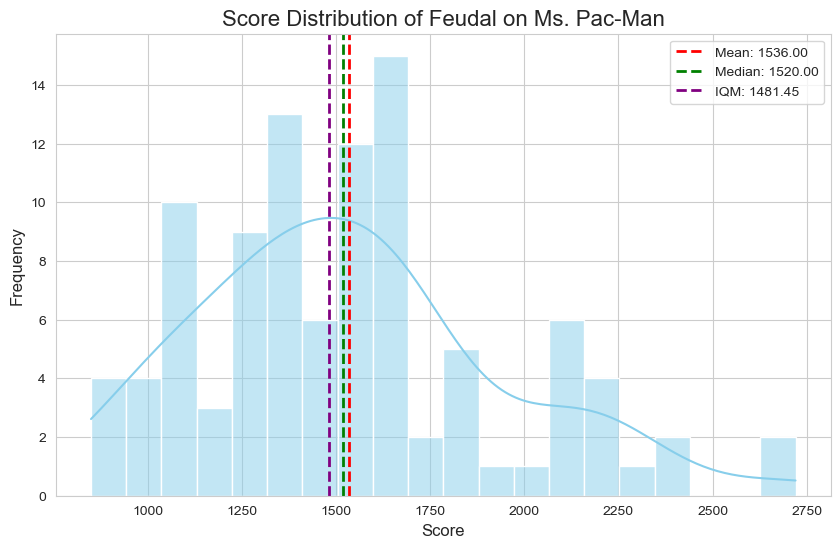

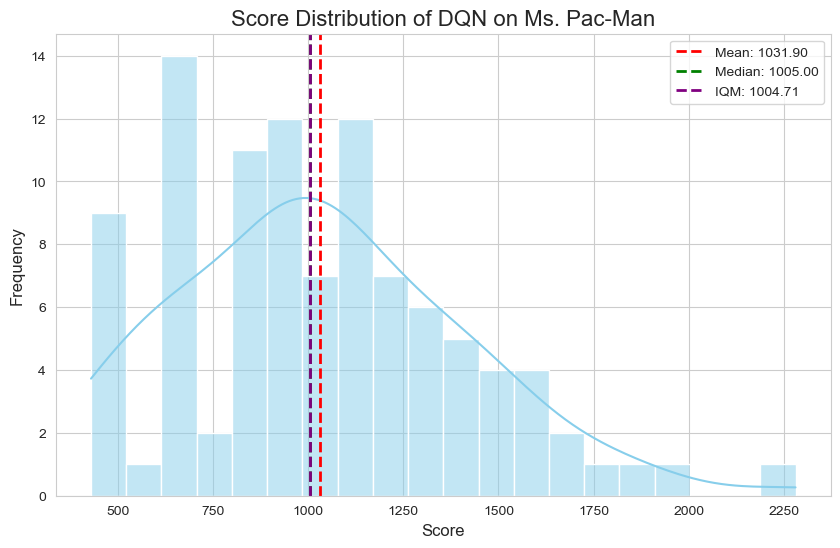

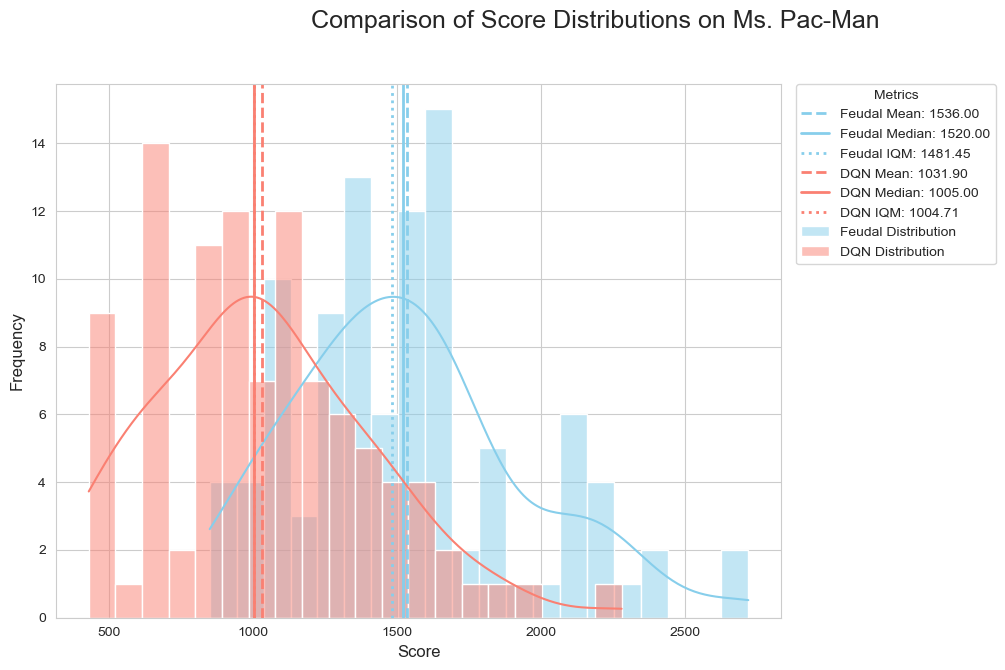

In [96]:
# Data load
sns.set_style("whitegrid")
raw_scores = {name: load_scores(path) for name, path in ALGORITHMS.items()}

for name, scores in raw_scores.items():
    plot_score_distribution(scores, name)

plot_score_distributions_overlapped(raw_scores)




Using DQN IQM as threshold: 0.1057
Normalized Score Point Estimates and 95% CIs

Model: Feudal, Metric: IQM
  Normalized Score (Point Estimate): 0.1787
  95% Confidence Interval:          (0.1673, 0.1901)

Model: DQN, Metric: IQM
  Normalized Score (Point Estimate): 0.1057
  95% Confidence Interval:          (0.0929, 0.1179)

Model: Feudal, Metric: Median
  Normalized Score (Point Estimate): 0.1824
  95% Confidence Interval:          (0.1643, 0.1914)

Model: DQN, Metric: Median
  Normalized Score (Point Estimate): 0.1049
  95% Confidence Interval:          (0.0929, 0.1177)

Model: Feudal, Metric: Mean
  Normalized Score (Point Estimate): 0.1848
  95% Confidence Interval:          (0.1731, 0.1967)

Model: DQN, Metric: Mean
  Normalized Score (Point Estimate): 0.1090
  95% Confidence Interval:          (0.0979, 0.1202)

Model: Feudal, Metric: Optimality Gap on QL-IQM
  Normalized Score (Point Estimate): 0.0012
  95% Confidence Interval:          (0.0003, 0.0022)

Model: DQN, Metric: Opti

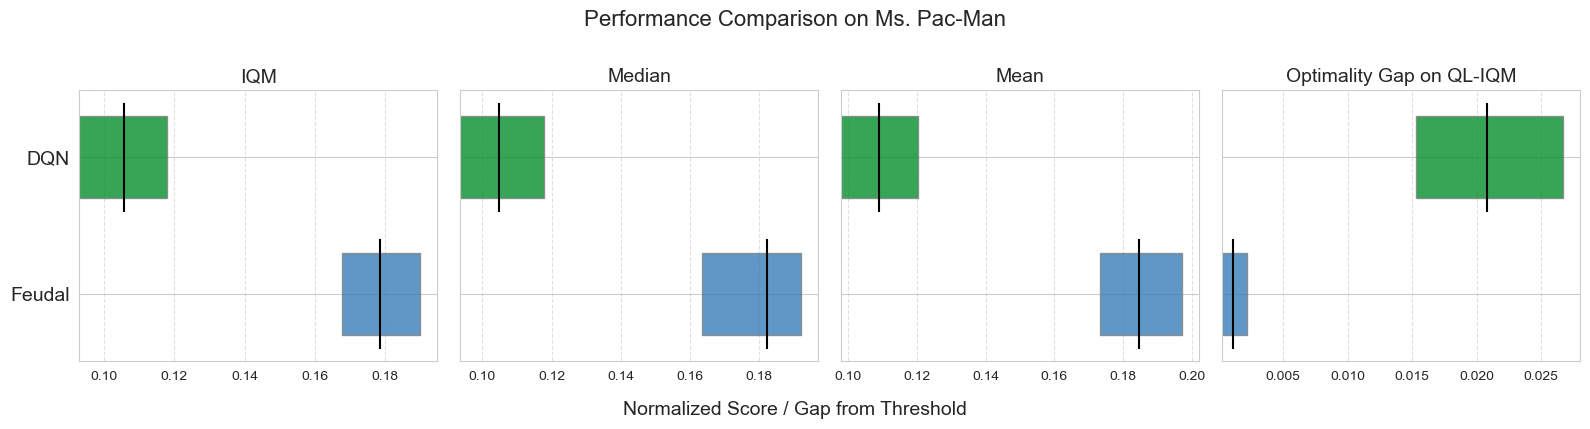

In [97]:
normalized_scores = {
    algo: (scores.astype(float) - RANDOM_SCORE) / (HUMAN_SCORE - RANDOM_SCORE)
    for algo, scores in raw_scores.items()
}

def calculate_iqm(data):
    """Calculates the Interquartile Median (IQM)."""
    q1, q3 = np.percentile(data, [25, 75])
    trimmed_data = data[(data >= q1) & (data <= q3)]
    return np.mean(trimmed_data) if len(trimmed_data) > 0 else np.mean(data)

def bootstrap_ci(data: np.ndarray, metric_func: Callable, n_bootstrap: int = 10000, ci_level: float = 0.95):
    """Calculates bootstrap confidence intervals for a given metric."""
    bootstrap_metrics = [metric_func(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_bootstrap)]
    alpha = (1 - ci_level) / 2
    lower = np.percentile(bootstrap_metrics, 100 * alpha)
    upper = np.percentile(bootstrap_metrics, 100 * (1 - alpha))
    return metric_func(data), lower, upper


qlearning_scores = normalized_scores['DQN']
DQN_IQM_THRESHOLD = metrics.aggregate_iqm(qlearning_scores)
print(f"Using DQN IQM as threshold: {DQN_IQM_THRESHOLD:.4f}")

# The gap metric now uses the pre-calculated DQN_IQM_THRESHOLD.
METRICS = {
    'IQM': metrics.aggregate_iqm,
    'Median': np.median,
    'Mean': np.mean,
    'Optimality Gap on QL-IQM': lambda x: metrics.aggregate_optimality_gap(x, metrics.aggregate_iqm(qlearning_scores))
}

print("Normalized Score Point Estimates and 95% CIs")
results = {}

for name, func in METRICS.items():
    for algo in ALGORITHMS.keys():
        if algo not in results:
            results[algo] = {}
        
        scores = normalized_scores.get(algo)
        if scores is None or scores.size == 0:
            print(f"Skipping {algo} for {name} (no data found)")
            continue

        # Calculate the point estimate and confidence interval
        point_est, lower, upper = bootstrap_ci(scores, func)
        
        # Store for potential later use
        results[algo][name] = {
            'score': point_est,
            'ci_lower': lower,
            'ci_upper': upper
        }
        
        # Print the results in a clean format
        print(f"\nModel: {algo}, Metric: {name}")
        print(f"  Normalized Score (Point Estimate): {point_est:.4f}")
        print(f"  95% Confidence Interval:          ({lower:.4f}, {upper:.4f})")

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, (name, func) in zip(axes, METRICS.items()):
    ax.set_title(name, fontsize=14)
    for i, algo in enumerate(ALGORITHMS.keys()):
        scores = normalized_scores[algo]
        point_est, lower, upper = bootstrap_ci(scores, func)
        ax.barh(y=i, width=(upper - lower), left=lower, height=0.6, color=COLORS[algo], alpha=0.8, edgecolor='grey')
        ax.vlines(x=point_est, ymin=i - 0.4, ymax=i + 0.4, color='black', lw=1.5)
        ax.grid(axis='x', linestyle='--', alpha=0.6)

axes[0].set_yticks(range(len(ALGORITHMS)))
axes[0].set_yticklabels(ALGORITHMS.keys(), fontsize=14)

# Updated x-axis label
fig.text(0.5, 0.02, 'Normalized Score / Gap from Threshold', ha='center', va='center', fontsize=14)
fig.suptitle("Performance Comparison on Ms. Pac-Man", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

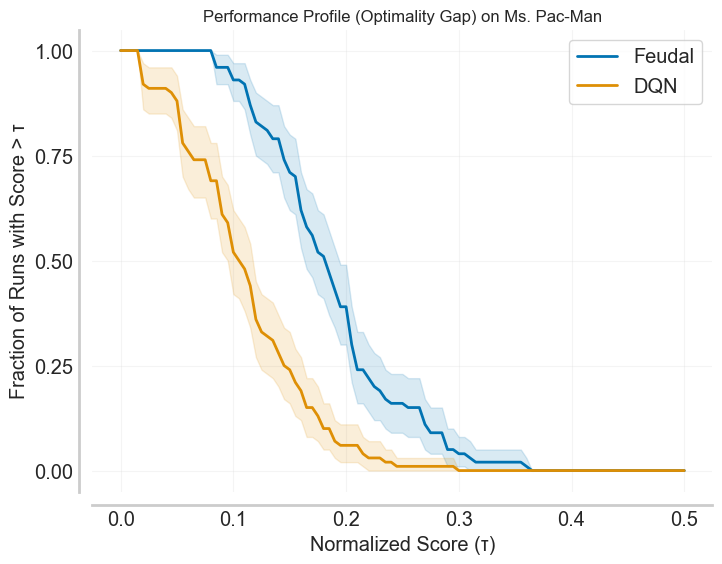

In [98]:


normalized_scores_2d = {
    algo: scores.reshape(-1, 1) 
    for algo, scores in normalized_scores.items()
}

thresholds = np.linspace(0.0, .5, 101) 

profiles, profile_cis = rly.create_performance_profile(
    normalized_scores_2d, thresholds, reps=10000 
)

fig, ax = plt.subplots(figsize=(8, 6))
plot_utils.plot_performance_profiles(profiles, thresholds, performance_profile_cis=profile_cis, ax=ax, legend=True)
ax.set_title('Performance Profile (Optimality Gap) on Ms. Pac-Man')
ax.set_xlabel('Normalized Score (τ)')
ax.set_ylabel('Fraction of Runs with Score > τ')
plt.grid(True)
plt.show()


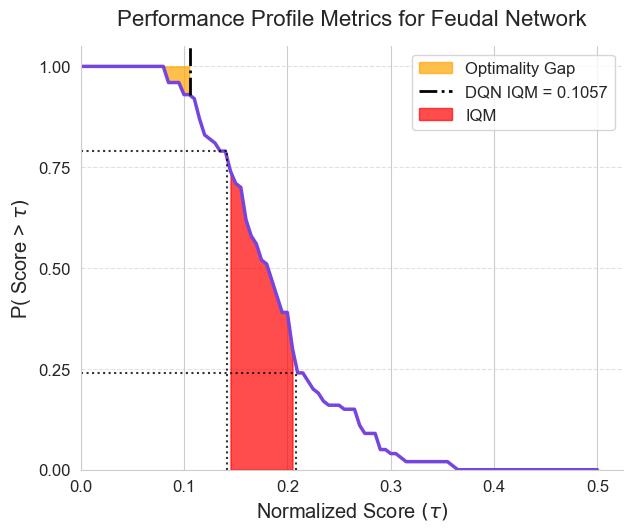

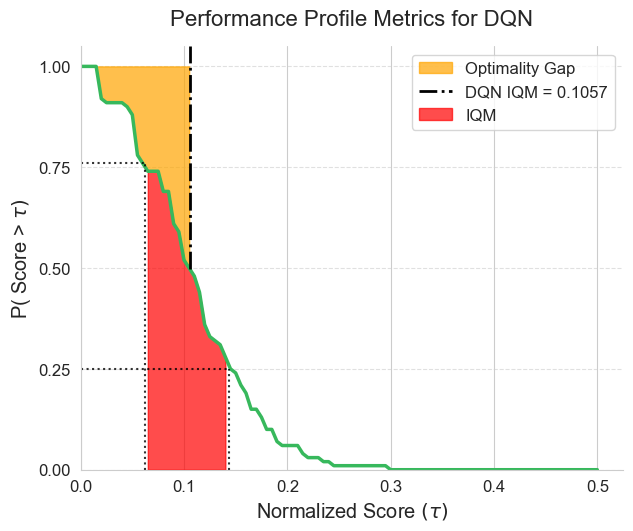

In [99]:
# Annotated Perf profiles
thresholds = np.linspace(0.0, .5, 101)
plot_annotated_profile(
    scores=normalized_scores['Feudal'],
    profile=profiles['Feudal'],
    thresholds=thresholds,
    algo_name='Feudal Network',
    color=COLORS['Feudal_Profile']
)

plot_annotated_profile(
    scores=normalized_scores['DQN'],
    profile=profiles['DQN'],
    thresholds=thresholds,
    algo_name='DQN',
    color=COLORS['Q_Profile']
)

Probabilities: {'Feudal_vs_DQN': np.float64(0.8224)}
95% CIs: {'Feudal_vs_DQN': array([[0.7615    ],
       [0.87755125]])}


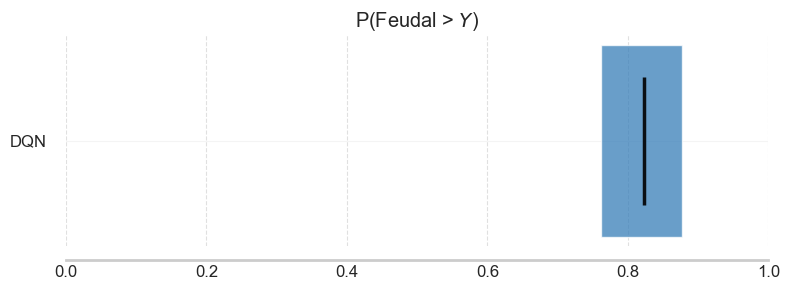

In [100]:

algorithm_pairs = {
    'Feudal_vs_DQN': (normalized_scores_2d['Feudal'], normalized_scores_2d['DQN'])
}

probabilities, probability_cis = rly.get_interval_estimates(
    algorithm_pairs, 
    metrics.probability_of_improvement, 
    reps=10000 
)

print(f"Probabilities: {probabilities}")
print(f"95% CIs: {probability_cis}")

fig, ax = plt.subplots(figsize=(8, 3)) 
h = 0.6 

for i, (alg_pair, prob) in enumerate(probabilities.items()):
    alg_X, alg_Y = alg_pair.split('_vs_')
    
    # Get the lower (l) and upper (u) bounds of the CI
    (l, u) = probability_cis[alg_pair]
    
    # Plot the 95% CI bar
    ax.barh(y=i, width=u-l, height=h,
            left=l, color=COLORS.get(alg_X, 'blue'), # Use color from your dict
            alpha=0.75)
    
    ax.vlines(x=prob, ymin=i - (h/2) + 0.1, ymax=i + (h/2) - 0.1,
              color='black', alpha=0.9, linewidth=2.5)
    
    ax.set_yticks([i])
    ax.set_yticklabels([alg_Y])

ax.set_title(fr'P({alg_X} > $Y$)', size='x-large')
ax.set_ylabel(r'Algorithm $Y$', size='large')
ax.set_xlabel('Probability of Improvement', size='large')

ax.set_xlim(0.0, 1.0)
ax.xaxis.set_major_locator(MaxNLocator(6)) 
plot_utils._annotate_and_decorate_axis(ax, labelsize='large', ticklabelsize='large')
ax.spines['left'].set_visible(False) # Remove left spine for a cleaner look

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()